# Exercise:
1. Write a code to simulate 2D-ISING model with N grid points per each dimension. 
2. Compute total energy of the system.
3. Compute magnetization of the system.
4. Plot the magnetization as the function of temperature.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## 1. Create initial configuration with $N^2$ sites
+ cold s= -1
+ random s= +1 or -1
+ hot s = 1

In [2]:
N = 20
grid_cold = np.ones((N, N))*-1
grid_random = np.random.choice(a=[-1,1], size=(N,N), replace=True)
grid_hot = np.ones((N,N))
print(grid_random)

[[ 1  1  1  1  1  1  1 -1 -1  1  1 -1  1 -1 -1  1 -1 -1 -1 -1]
 [ 1 -1  1 -1 -1  1 -1 -1  1  1 -1 -1 -1  1 -1  1  1  1 -1  1]
 [ 1 -1  1 -1  1 -1 -1 -1 -1  1 -1 -1 -1  1 -1  1 -1 -1  1 -1]
 [-1 -1 -1 -1  1 -1  1  1  1 -1  1 -1 -1  1  1  1  1 -1 -1 -1]
 [-1 -1  1  1  1  1  1 -1  1  1  1 -1  1  1 -1 -1 -1 -1  1  1]
 [-1 -1 -1 -1 -1  1 -1  1 -1  1 -1 -1 -1  1 -1 -1  1  1  1  1]
 [-1 -1  1 -1 -1 -1  1 -1 -1 -1 -1  1  1  1  1 -1  1 -1  1  1]
 [-1  1  1  1  1  1  1 -1 -1 -1  1  1  1 -1  1  1  1 -1 -1  1]
 [-1 -1  1 -1 -1 -1  1 -1  1 -1 -1 -1  1 -1 -1  1  1 -1 -1 -1]
 [-1 -1 -1  1  1  1  1  1 -1  1 -1  1 -1 -1 -1 -1 -1  1  1  1]
 [ 1 -1  1 -1 -1  1  1  1 -1 -1 -1  1  1 -1  1  1  1  1 -1 -1]
 [-1  1  1 -1 -1  1 -1  1 -1  1  1 -1 -1 -1  1 -1  1 -1 -1 -1]
 [ 1  1  1  1  1 -1  1 -1 -1  1  1 -1  1  1 -1 -1 -1 -1 -1  1]
 [ 1 -1  1 -1 -1 -1  1  1 -1 -1  1  1  1 -1  1  1  1  1  1  1]
 [-1  1  1 -1  1  1  1  1  1  1 -1 -1  1 -1  1 -1  1 -1 -1 -1]
 [-1 -1  1 -1 -1  1 -1  1 -1  1 -1 -1  1 -1  1 -1 -1 -1

## 2. Compute changing energy, at lattice point $i,j$

$\Delta E = E_{final} - E_{initial}$

In [3]:
def local_spin_energy_change(grid, i, j, J=1, B=0):
    '''
    function switch the spin at specific index and checks how it would effect the total energy. Does not affect the grid

    :param grid: old grid
    :param i: x index in grid
    :param j: y index in grid
    :param J: interaction strength
    :param B: external field
    :return: value of local spin energy change
    '''
    N = len(grid)
    old_spin = grid[i, j]
    neighbours = (
        grid[(i-1)%N,j] +
        grid[(i+1)%N,j] +
        grid[i,(j-1)%N] +
        grid[i,(j+1)%N]
    )

    return 2 * old_spin  * (J * neighbours  + B)
print(local_spin_energy_change(grid_cold, 6,8))

8.0


## 3. Generate new configuration using Monte Carlo Metropolis method
+ if $\Delta E <= 0$, accept new spin or flip spin
+ if $\Delta E > 0$, flip spin based on Boltzmann distribution:

	- $p <= e^{-\beta \Delta E}$: accept new spin

	- $p > e^{-\beta \Delta E}$: reject new spin

In [4]:
def visualize_grid(grid):
    cmap = plt.cm.coolwarm

    heatmap = sns.heatmap(
        grid,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        cbar=False,
    )

    plt.show()

In [5]:
def monte_carlo_metropolis_step(grid, beta):
    def __boltzmann_probability(delta_e, beta):
        return np.exp(-beta * delta_e)

    N = len(grid)

    for _ in range(N * N):
        random_index = np.random.randint(N * N)
        x_ind = random_index // N
        y_ind = random_index % N

        delta_e = local_spin_energy_change(grid, x_ind, y_ind)

        # Logika Metropolis
        if delta_e <= 0:
            grid[x_ind, y_ind] *= -1
        else:
            if np.random.random() <= __boltzmann_probability(delta_e, beta):
                grid[x_ind, y_ind] *= -1

    return grid

<class 'numpy.ndarray'>


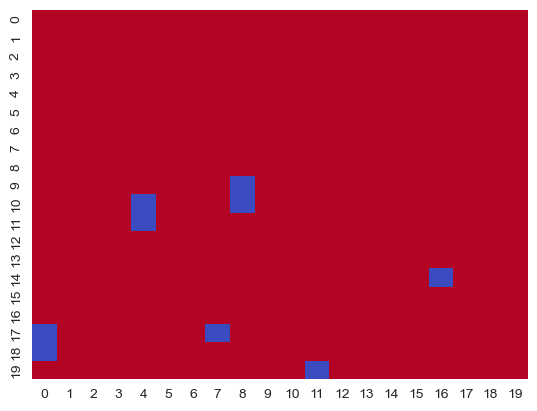

In [6]:
def ising_simulation(grid, step_func, beta, steps):
    _grid = grid.copy()
    for _ in range(steps):
        _grid = step_func(_grid, beta)
    return _grid

grid_after = ising_simulation(grid_hot, monte_carlo_metropolis_step, 0.6, 100)
print(type(grid_after))
visualize_grid(grid_after)


## 4. Compute 2 quatities:

### A. total energy of the system

$$E = -\sum_{i,j} s_i s_j$$

where $i,j$ are neighbourhoods.


In [7]:
# doing it with matrix'ies
def get_total_energy_system(grid, J=1.0, B=0.0):
    # if we do this, then we are going to do nice multiplication of x positoon with its right and down neighbour, which will eventualnny cover whole grid of unique pairs :)
    right_neighbours = np.roll(grid, 1, axis=1)
    down_neighbours = np.roll(grid, 1, axis=0)

    # print("="*6, "NORMAL", "="*6)
    # print(grid)
    # print("="*6, "Right roll", "="*6)
    # print(right_neighbours)
    # print("="*6, "NORMAL", "="*6)
    # print(grid)
    # print("="*6, "Down roll", "="*6)
    # print(down_neighbours)

    spin_sum = -1 * J * np.sum(grid * (right_neighbours + down_neighbours))


    if B != 0.0:
        field_sum = -1*B*np.sum(grid)
    else:
        field_sum = 0.0

    return spin_sum + field_sum

In [8]:
get_total_energy_system(grid_random)

-12.0

### B. Compute magnetization for each configuration after burn-in period

$$ \langle |M| \rangle = \dfrac{1}{n}\sum_{i =1}^{n} |M_i|$$
 with $n$ is the number of configurations and
$$M_i = \dfrac{1}{N^2}\sum_{j=1}^{N^2} s_j$$

In [9]:
def ising_simulation_with_stats(grid, step_func, beta, steps, burn_in_steps=0):
    active_steps = steps - burn_in_steps
    if active_steps <= 0:
        print("[WARNING] burn_in_steps is more or equal than the number of steps")
        return grid, 0, 0, 0

    _grid = grid.copy()
    _sum_mag = 0.0
    _sum_mag_sq = 0.0
    N_sq = len(grid)**2


    bar = range(steps)

    for i in bar:
        _grid = step_func(_grid, beta)

        if i >= burn_in_steps:
            current_m = np.abs(np.sum(_grid)) / N_sq
            _sum_mag += current_m
            _sum_mag_sq += current_m**2

    avg_mag = _sum_mag / active_steps
    avg_mag_sq = _sum_mag_sq / active_steps

    _susceptibility = beta * N_sq * (avg_mag_sq - (avg_mag**2))

    _total_en = get_total_energy_system(_grid, J=1, B=0.0)

    return _grid, avg_mag, _total_en, _susceptibility

_, hot_total_magnetism, hot_total_energy, hot_total_susceptibility = ising_simulation_with_stats(grid=grid_hot, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200)
_, cold_total_magnetism, cold_total_energy, cold_total_susceptibility = ising_simulation_with_stats(grid=grid_cold, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200)
_, rand_total_magnetism, rand_total_energy, rand_total_susceptibility = ising_simulation_with_stats(grid=grid_random, step_func=monte_carlo_metropolis_step, beta=0.6, steps=5000, burn_in_steps=200)



print("="*6, "Hot Grid", "="*6)
print("Total magnetism:\n ", hot_total_magnetism, "Total energy: \n", hot_total_energy, "Total susceptibility: \n", hot_total_susceptibility)
print("="*6, "Cold Grid", "="*6)
print("Total magnetism: \n", cold_total_magnetism, "Total energy: \n", cold_total_energy, "Total susceptibility: \n", cold_total_susceptibility)
print("="*6, "Cold Grid", "="*6)
print("Total magnetism: \n", rand_total_magnetism, "Total energy: \n", rand_total_energy, "Total susceptibility: \n", rand_total_susceptibility)


====== Hot Grid ======
Total magnetism:
  0.9731874999999761 Total energy: 
 -772.0 Total susceptibility: 
 0.05938656251228025
====== Cold Grid ======
Total magnetism: 
 0.9736187499999767 Total energy: 
 -748.0 Total susceptibility: 
 0.05750961563590451
====== Cold Grid ======
Total magnetism: 
 0.9734489583333076 Total energy: 
 -748.0 Total susceptibility: 
 0.05901637475162147


### C. Plot the magnetization and energy  as the function of $\beta$.


In [10]:
mag = []
tot_en = []
sus = []

steps = 7000
burn_in_steps = 1000

bar = tqdm(np.arange(0,1, 0.05))
for beta in bar:
    bar.set_description(f"Beta: {beta:.2f}")
    _, hot_mag, hot_en, hot_sus = ising_simulation_with_stats(grid=grid_hot, step_func=monte_carlo_metropolis_step, beta=beta, steps=steps, burn_in_steps=burn_in_steps)
    _, cold_mag, cold_en, cold_sus = ising_simulation_with_stats(grid=grid_cold, step_func=monte_carlo_metropolis_step, beta=beta, steps=steps, burn_in_steps=burn_in_steps)
    _, rand_mag, rand_en, rand_sus = ising_simulation_with_stats(grid=grid_random, step_func=monte_carlo_metropolis_step, beta=beta, steps=steps, burn_in_steps=burn_in_steps)

    mag.append([hot_mag, cold_mag, rand_mag])
    tot_en.append([hot_en, cold_en, rand_en])
    sus.append([hot_sus, cold_sus, rand_sus])

Beta: 0.95: 100%|██████████| 20/20 [08:10<00:00, 24.52s/it]


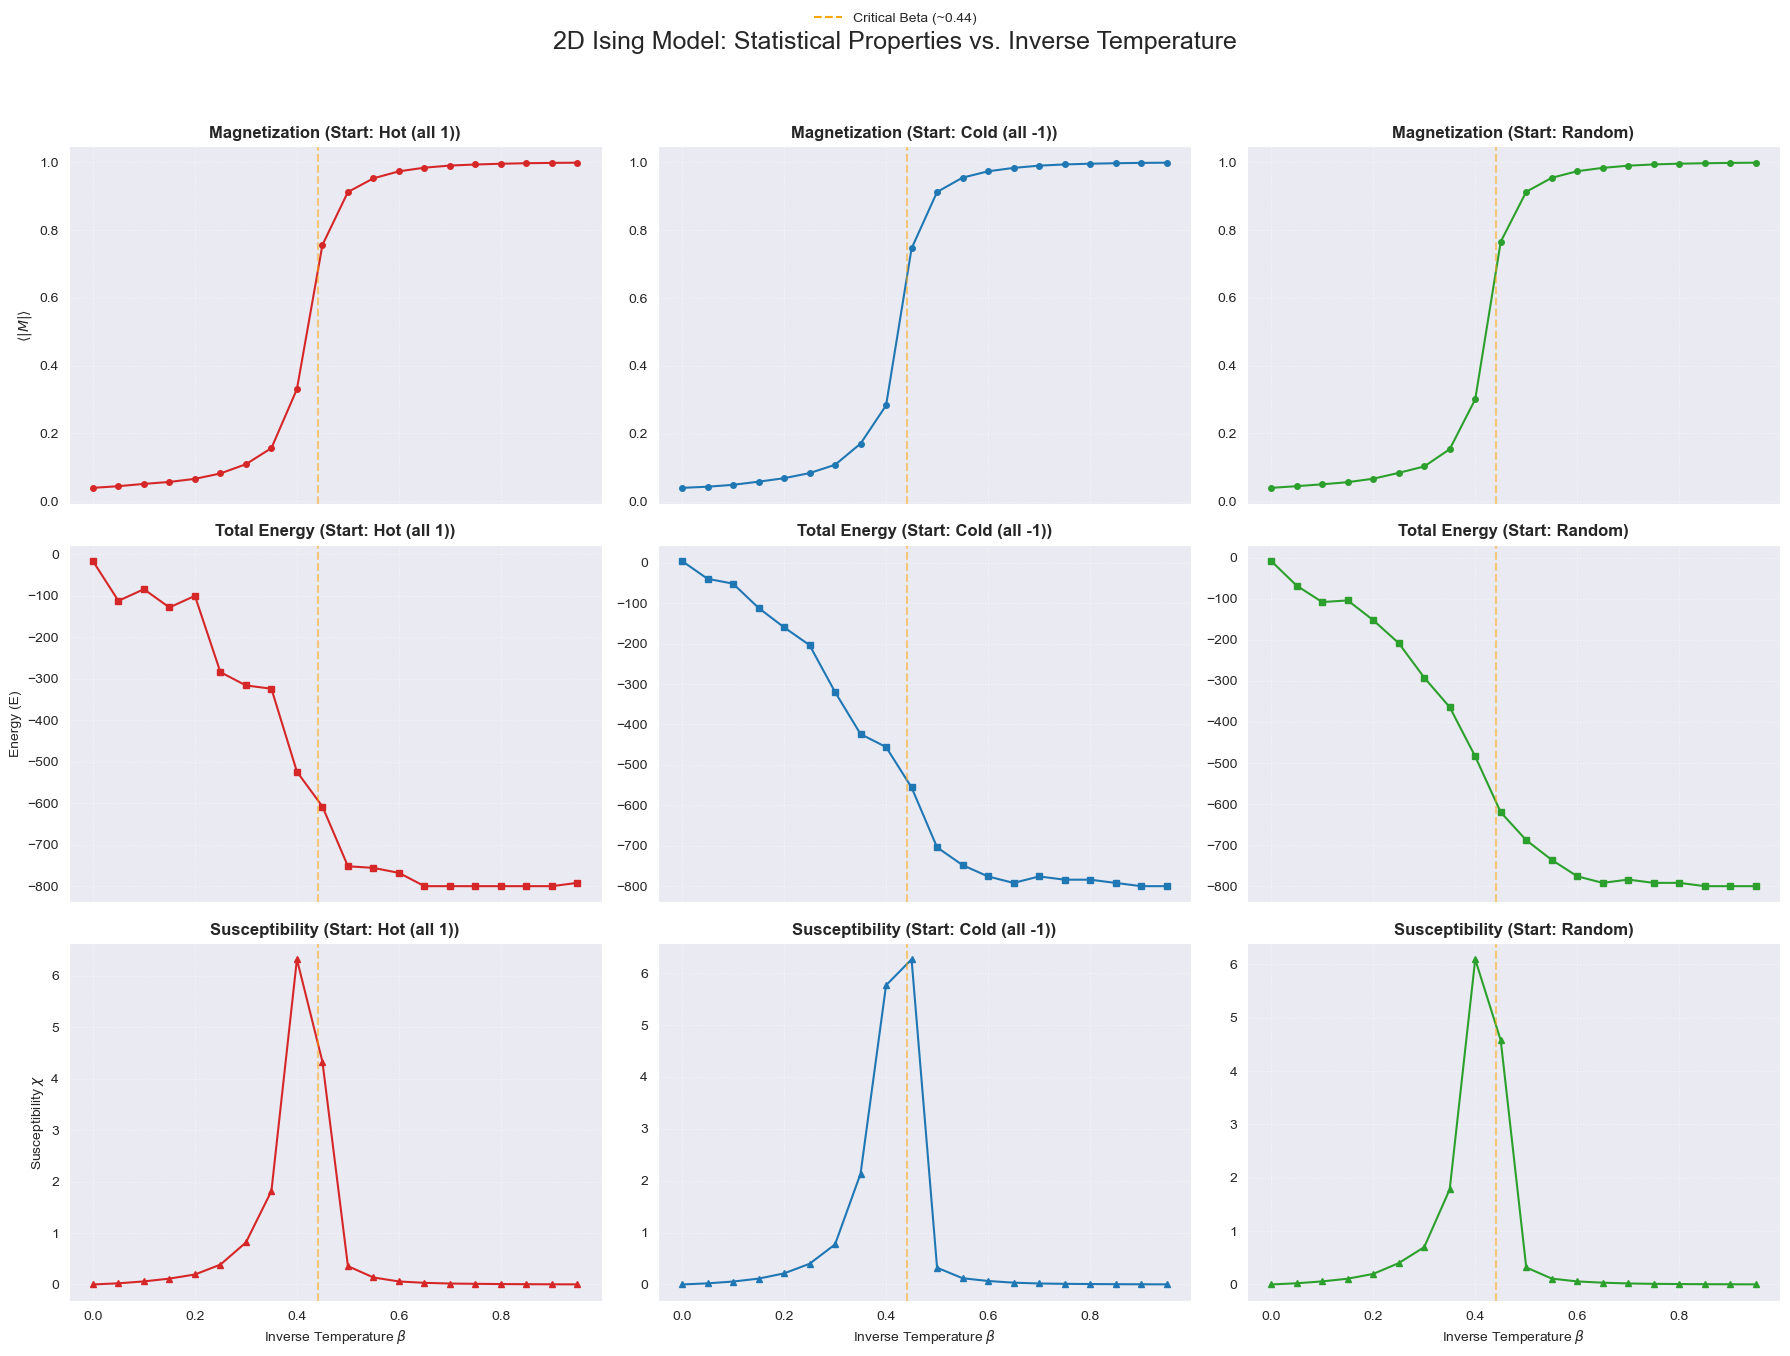

In [11]:
mag_arr = np.array(mag)
en_arr = np.array(tot_en)
sus_arr = np.array(sus)
betas = np.arange(0, 1, 0.05)
labels = ['Start: Hot (all 1)', 'Start: Cold (all -1)', 'Start: Random']
colors = ['#d62728', '#1f77b4', '#2ca02c']
critical_beta = 0.4407

fig, axs = plt.subplots(3, 3, figsize=(18, 14), sharex=True)

for i in range(3):
    # --- Row 1: Magnetization ---
    axs[0, i].plot(betas, mag_arr[:, i], 'o-', color=colors[i], markersize=4)
    axs[0, i].set_title(f"Magnetization ({labels[i]})", fontweight='bold')
    axs[0, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
    axs[0, i].grid(True, linestyle=':', alpha=0.6)
    if i == 0: axs[0, i].set_ylabel(r"$\langle |M| \rangle$")

    # --- Row 2: Total Energy ---
    axs[1, i].plot(betas, en_arr[:, i], 's-', color=colors[i], markersize=4)
    axs[1, i].set_title(f"Total Energy ({labels[i]})", fontweight='bold')
    axs[1, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
    axs[1, i].grid(True, linestyle=':', alpha=0.6)
    if i == 0: axs[1, i].set_ylabel("Energy (E)")

    # --- Row 3: Susceptibility ---
    axs[2, i].plot(betas, sus_arr[:, i], '^-', color=colors[i], markersize=4)
    axs[2, i].set_title(f"Susceptibility ({labels[i]})", fontweight='bold')
    axs[2, i].set_xlabel(r"Inverse Temperature $\beta$")
    axs[2, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
    axs[2, i].grid(True, linestyle=':', alpha=0.6)
    if i == 0: axs[2, i].set_ylabel(r"Susceptibility $\chi$")

axs[0, 0].plot([], [], color='orange', linestyle='--', label='Critical Beta (~0.44)')
fig.legend(loc='upper center', ncol=1, frameon=False)

plt.suptitle("2D Ising Model: Statistical Properties vs. Inverse Temperature", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

> Comment
>
> In general we can see that the plot is reversed(i compare it to how it was in the lecture), it is because we have $\beta$ which is inversed temperature... We can see that my algorithm nicely simulates the Ising model, we can see critical value (i just copied it from theory which should be around 0.44). It aligns with theory.